# 《AI思维》第 5 章 · 校园图搜索 — Python 实验

> 配套 [ch5.html](../ch5.html) · 预计 **18 分钟** · 建议先浏览网页「搜索实验室」，再读本 notebook。

**本节带走什么**
- 能说出五种搜索的**待探索结构**（栈 / 队列 / 优先队列）各是什么
- 能解释 **BFS 2 步 ≠ 代价最优**（本例 BFS 代价 8，UCS/A* 代价 7）
- 能预测从校门口 `x` 出发时，A* 第一步为何不选超市 `c2`

## 1. 统一案例：与网页同一张校园图

搜索不是抽象公式，而是在**同一张状态图**上比较「下一步选谁」。本实验与 ch5 动画使用完全相同的节点、边权与启发式 h。

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / "labs").exists() and (ROOT.parent / "labs").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "labs" / "ch05"))
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["PingFang SC", "Heiti SC", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
from IPython.display import display
from search_algorithms import *
graph = load_graph()
print(f"起点 {graph['start']} → 目标 {graph['goal']}（操场）")
display(graph_summary())
display(edges_table())

起点 x → 目标 c1（操场）


,节点,名称,h(到操场)
6,c1,操场,0
1,c2,超市,1
2,j,教学楼,4
4,s1,食堂,3
3,s2,实验楼,4
5,t,图书馆,2
0,x,校门口,7


,边,代价
0,x↔c2,7
1,x↔j,2
2,x↔s1,2
3,j↔s2,4
4,s2↔s1,1
5,s1↔t,3
6,s1↔c1,6
7,t↔c1,2


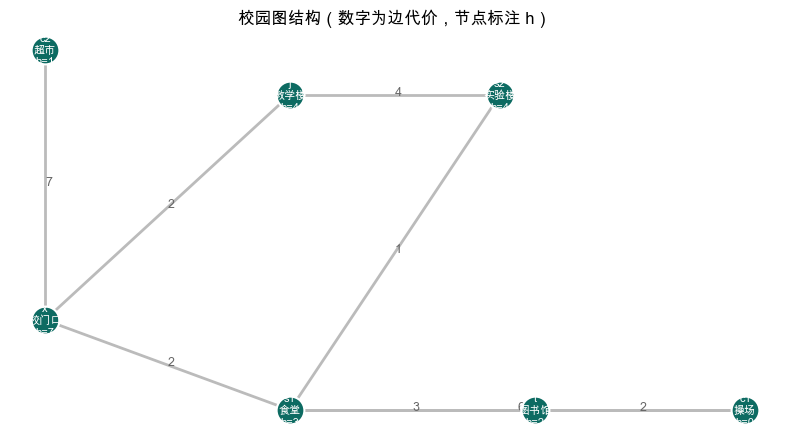

In [2]:
plot_campus(title='校园图结构（数字为边代价，节点标注 h）')

**🤔 预测** · 从 x 出发，三个直接邻居是谁？若用 **BFS（队列）**，第一层会按什么顺序入队？先写下答案再运行下一格。

In [3]:
display(neighbors_table("x"))
# 字母序：c2(7), j(2), s1(2) — 与网页一致

,邻居,边代价,h
0,c2,7,1
1,j,2,4
2,s1,2,3


## 2. 广度优先 BFS：水波层序扩散

**心智模型**：水波从起点一圈圈向外；**队头**永远是「离起点步数最少」的节点。

↔ 网页 [ch5.html](../ch5.html) 模块 m1 · BFS 步进动画

**⚠️ 误区** · BFS 最优 ≠ 代价最优。BFS 保证**最少边数**；边权不同时要用 UCS。

In [4]:
manual_bfs_two_steps()

初始 frontier = deque(['x'])
第 1 步：弹出 x，按字母序入队 c2, j, s1
  frontier = ['c2', 'j', 's1']
第 2 步：弹出 c2（队头），无新目标；再弹出 j…
  …直到队头为 s1 时展开，发现邻居 c1=目标
最终路径：x → s1 → c1（2 步，代价 8）


In [5]:
trace_bfs = trace_search("bfs")
display(trace_bfs.head(6))
path_bfs = run_all()["bfs"]["path"]
print("路径:", "→".join(path_bfs), "  代价:", path_cost(path_bfs, build_adjacency(graph["edges"])))

,步,弹出,g,h,frontier,visited,到达?
0,1,x,0,7,∅,x,False
1,2,c2,7,1,j→s1,c2→x,False
2,3,j,2,4,s1,c2→j→x,False
3,4,s1,2,3,s2,c2→j→s1→x,False
4,5,s2,6,4,c1→t,c2→j→s1→s2→x,False
5,6,c1,8,0,t,c1→c2→j→s1→s2→x,True


路径: x→s1→c1   代价: 8


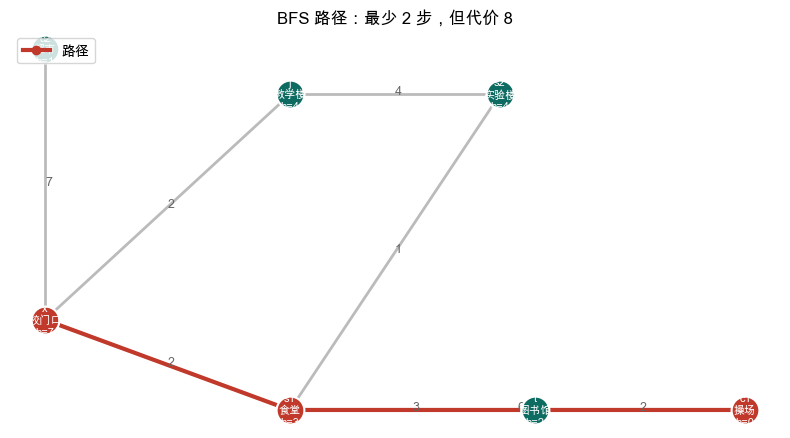

In [6]:
plot_campus(path_bfs, title='BFS 路径：最少 2 步，但代价 8')

**✅ 自测** · BFS 2 步、DFS 4 步——差别来自**待探索结构（栈 vs 队列）**还是启发式 h？

## 3. 深度优先 DFS：栈 + 走到底再回溯

**心智模型**：迷宫里选一条道走到黑，死路就回到最近岔口。本图 DFS 先深入 `j→s2→s1`，步数 4、代价 13。

,步,弹出,g,h,frontier,visited,到达?
0,1,x,0,7,∅,x,False
1,2,c2,7,1,s1→j,c2→x,False
2,3,j,2,4,s1,c2→j→x,False
3,4,s2,6,4,s1,c2→j→s2→x,False
4,5,s1,2,3,∅,c2→j→s1→s2→x,False
5,6,c1,8,0,t,c1→c2→j→s1→s2→x,True


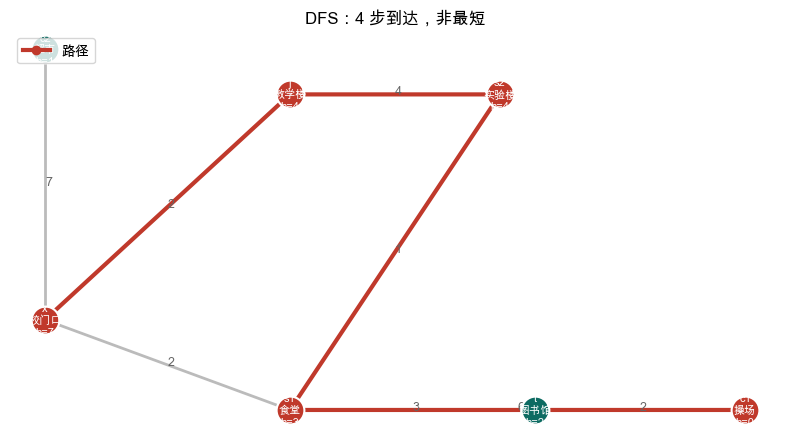

In [7]:
trace_dfs = trace_search("dfs")
display(trace_dfs)
plot_campus(run_all()["dfs"]["path"], title='DFS：4 步到达，非最短')

## 4. 一致代价 UCS：按累计 g 排队

UCS 的优先队列键是 **g(n)**——从起点走到这里的真实花费。本例最优路径 `x→s1→t→c1`，代价 **7**。

,步,弹出,g,h,frontier,visited,到达?
0,1,x,0,7,∅,x,False
1,2,j,2,4,s1→c2,j→x,False
2,3,s1,2,3,s2→c2,j→s1→x,False
3,4,s2,3,4,t→c2→c1,j→s1→s2→x,False
4,5,t,5,2,c2→c1,j→s1→s2→t→x,False
5,6,c1,7,0,c2,c1→j→s1→s2→t→x,True


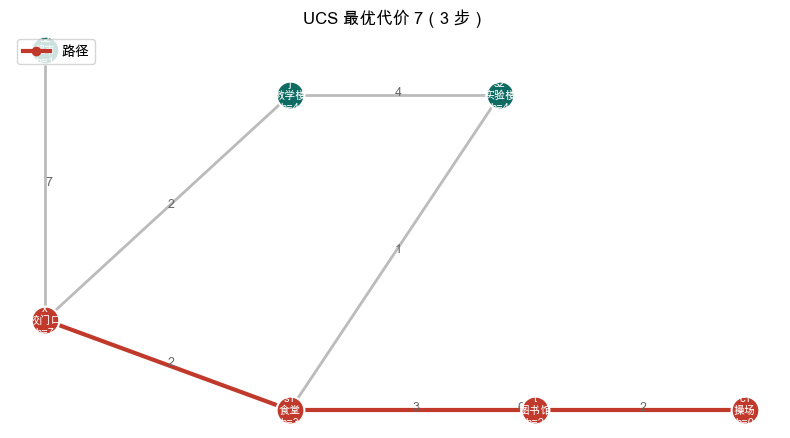

In [8]:
display(trace_search("ucs"))
plot_campus(run_all()["ucs"]["path"], title='UCS 最优代价 7（3 步）')

**📌 小结** · BFS 2 步但代价 8；UCS 3 步代价 7——**步数最少 ≠ 花费最少**，这是第 5 章要建立的判断力。

## 5. 贪婪 & A*：启发式 h 与 f=g+h

In [9]:
print("从 x 出发第一步 — 各邻居 g、h、f：")
display(first_step_scores())
print("\nGreedy 只看 h 最小 → 先展开 s1；A* 看 f=g+h → 同样先展开 s1（f=5），而非超市 c2（f=8）")

从 x 出发第一步 — 各邻居 g、h、f：


,邻居,g,h,f=g+h,名称
2,s1,2,3,5,食堂
1,j,2,4,6,教学楼
0,c2,7,1,8,超市



Greedy 只看 h 最小 → 先展开 s1；A* 看 f=g+h → 同样先展开 s1（f=5），而非超市 c2（f=8）


,算法,路径,步数,代价,与网页
0,DFS,x→j→s2→s1→c1,4,13,✓
1,BFS,x→s1→c1,2,8,✓
2,UCS,x→s1→t→c1,3,7,✓
3,Greedy,x→s1→c1,2,8,✓
4,A*,x→s1→t→c1,3,7,✓


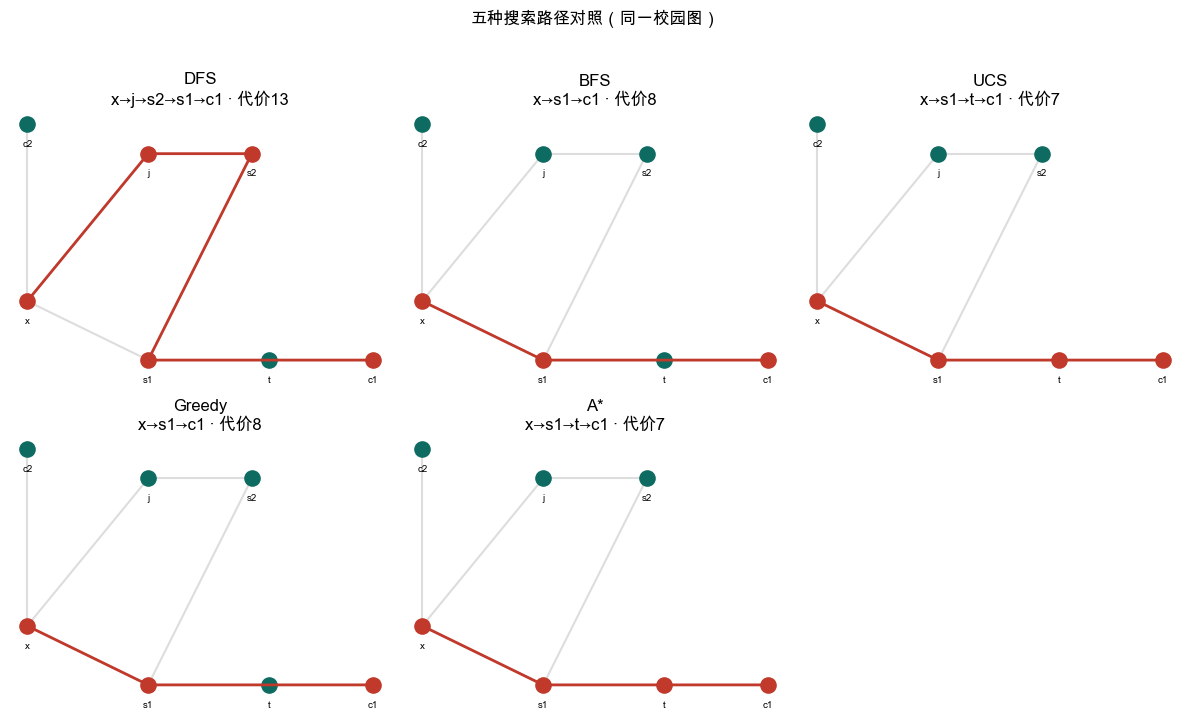

In [10]:
display(comparison_table())
plot_all_paths()

## 6. 汇总对照与验证

| 对比维度 | 本实验读法 |
|----------|------------|
| 待探索结构 | DFS 栈 / BFS 队列 / UCS·Greedy·A* 优先队列 |
| 信息来源 | 无 / g / h / g+h |
| 本图结论 | 仅 UCS 与 A* 得最低代价 7；BFS·Greedy 步数少但贵 |

**与网页互补**：动画看 frontier 变化；notebook 看 trace 表与路径图。回到 [ch5.html](../ch5.html) 实验室，尝试预测下一步再点步进。

In [11]:
verify_against_web()

✓ 五种算法路径与 ch5.html 完全一致


### 思考题
1. 若所有边代价都是 1，BFS 与 UCS 路径会相同吗？
2. 若超市 h 被错误设为 0，Greedy 第一步会怎样？
3. MiniMax 在网页中是第六种「搜索」——它解决的是**博弈树**而非 campus 找路，对手会选对你最差的应对。

完整实现见 `labs/ch05/search_algorithms.py`。